In [1]:
import os
import cv2
import imghdr
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

/tmp/ipykernel_76157/1228204448.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr
I0000 00:00:1782615867.666067   76157 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782615873.901731   76157 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782615886.748266   76157 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Cleaning Images

In [2]:
data_dir = 'Images/'

In [3]:
image_extensions = ['jpg', 'jpeg', 'png', 'bmp']

In [4]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            image_type = imghdr.what(image_path)
            if image_type not in image_extensions:
                print(f'{image_path} is not a valid image')
                os.remove(image_path)
        except Exception as e:
            print(f'Error processing {image_path}: {e}')

Invalid SOS parameters for sequential JPEG


# Data Preprocessing

In [5]:
data = tf.keras.utils.image_dataset_from_directory(data_dir)

Found 6031 files belonging to 17 classes.


E0000 00:00:1782615992.352646   76157 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [6]:
data_iterators = data.as_numpy_iterator()
batch = next(data_iterators)
batch[1].max()


W0000 00:00:1782615993.052801   76258 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


np.int32(16)

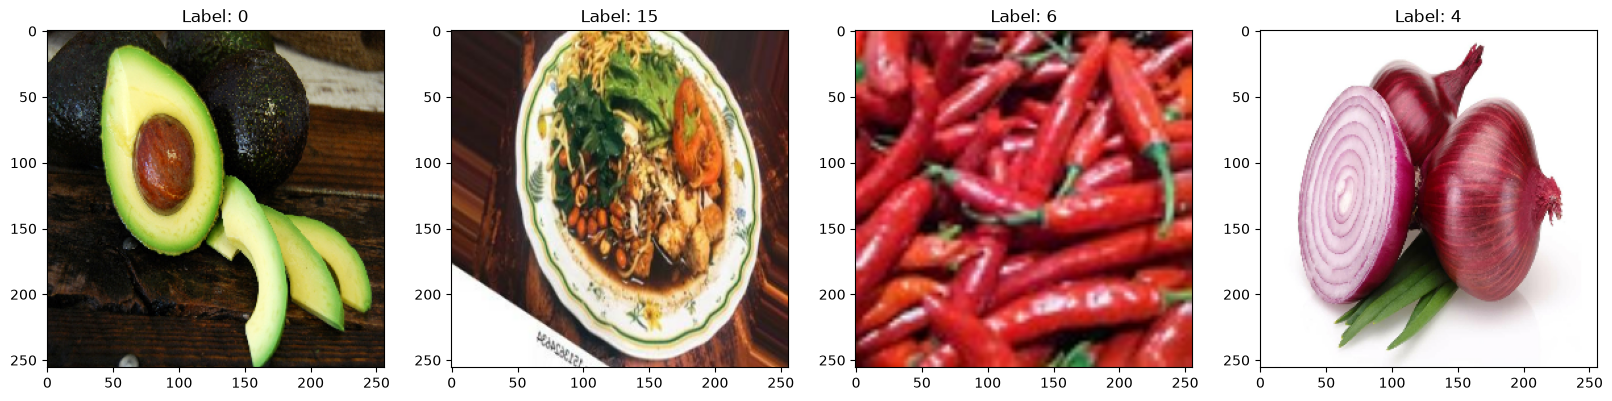

In [7]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, image in enumerate(batch[0][:4]):
    ax[idx].imshow(image.astype(int))
    ax[idx].title.set_text(f'Label: {batch[1][idx]}')

In [8]:
from pathlib import Path
import pandas as pd
import os

data_dir = 'Images/'
data_dir_path = Path(data_dir)

# PERBAIKAN: Mengambil gambar .jpg, .jpeg, dan .png sekaligus
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
filepaths = []
for ext in image_extensions:
    filepaths.extend(list(data_dir_path.glob(f'**/{ext}')))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

category_samples = []
for category in images['Label'].unique():
    category_slice = images.query("Label == @category")
    max_sample = min(300, len(category_slice))  # Membatasi maksimal 300 gambar
    category_samples.append(category_slice.sample(max_sample, random_state=1))

image_df = pd.concat(category_samples, axis=0).sample(frac=1.0, random_state=1).reset_index(drop=True)

# Mengecek apakah 17 folder sudah terbaca semua
print(f"Total gambar yang berhasil dimuat: {len(image_df)}")
print(f"Total kategori makanan: {len(image_df['Label'].unique())}")

Total gambar yang berhasil dimuat: 5076
Total kategori makanan: 17


In [9]:
image_df['Label'].value_counts()

Label
Cabe Rawit         300
Sate Ayam          300
Pisang             300
Telur Mata Sapi    300
Bakso              300
Alpukat            300
Bawang Bombai      300
Nasi Putih         300
Tempe Goreng       300
es krim            300
Ayam Goreng        300
Mangga             300
kupat tahu         300
rendang            300
Bawang Merah       297
Tahu Goreng        293
Bawang Putih       286
Name: count, dtype: int64

Split Data

In [10]:
train_df, test_df = train_test_split(
    image_df, 
    train_size=0.8, 
    shuffle=True, 
    random_state=1)

In [11]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [12]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 3248 validated image filenames belonging to 17 classes.
Found 812 validated image filenames belonging to 17 classes.
Found 1016 validated image filenames belonging to 17 classes.


# Pre-Trained

In [13]:
from tensorflow.keras.regularizers import l2

res_base = tf.keras.applications.ResNet152V2(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
res_base.trainable = False

inputs = res_base.input

x = res_base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation='leaky_relu', kernel_regularizer=l2(0.001))(x)
outputs = tf.keras.layers.Dense(17, activation='softmax', kernel_regularizer=l2(0.001))(x)
model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,516,433 (227.04 MB)

 Trainable params: 1,184,785 (4.52 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

None


# Training

In [14]:
from tensorflow.keras.optimizers import Adamax

# Compile the model
model.compile(optimizer=Adamax(learning_rate=1e-3), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [15]:
# Define callbacks for early stopping and model checkpoint
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Train the model with frozen layers
history1 = model.fit(train_images, epochs=5, verbose=1, validation_data=val_images, callbacks=callbacks, shuffle=False)

Epoch 1/5


I0000 00:00:1782616004.159701   76157 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1782616019.952734   76249 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.
W0000 00:00:1782616020.262158   76249 cpu_allocator_impl.cc:82] Allocation of 106463232 exceeds 10% of free system memory.
W0000 00:00:1782616020.339016   76250 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.
W0000 00:00:1782616020.462470   76249 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.
W0000 00:00:1782616020.515821   76249 cpu_allocator_impl.cc:82] Allocation of 102760448 exceeds 10% of free system memory.


 13/102 ━━━━━━━━━━━━━━━━━━━━ 9:22 6s/step - accuracy: 0.3149 - loss: 3.5230

/home/afh/coding/model/ML/ml-env/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6487 - loss: 2.2221
Epoch 1: val_loss improved from None to 1.58988, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 848s 8s/step - accuracy: 0.6487 - loss: 2.2221 - val_accuracy: 0.8374 - val_loss: 1.5899
Epoch 2/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8374 - loss: 1.5459
Epoch 2: val_loss improved from 1.58988 to 1.42162, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 772s 8s/step - accuracy: 0.8374 - loss: 1.5459 - val_accuracy: 0.8732 - val_loss: 1.4216
Epoch 3/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8833 - loss: 1.3663
Epoch 3: val_loss improved from 1.42162 to 1.32302, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 814s 8s/step - accuracy: 0.8833 - loss: 1.3663 - val_accuracy: 0.8916 - val_loss: 1.3

In [16]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 88.78%


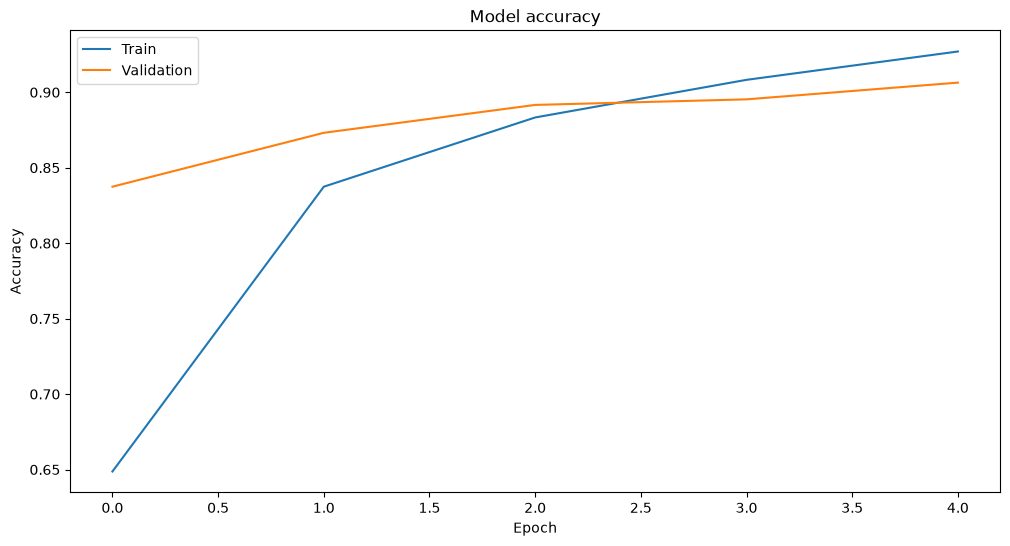

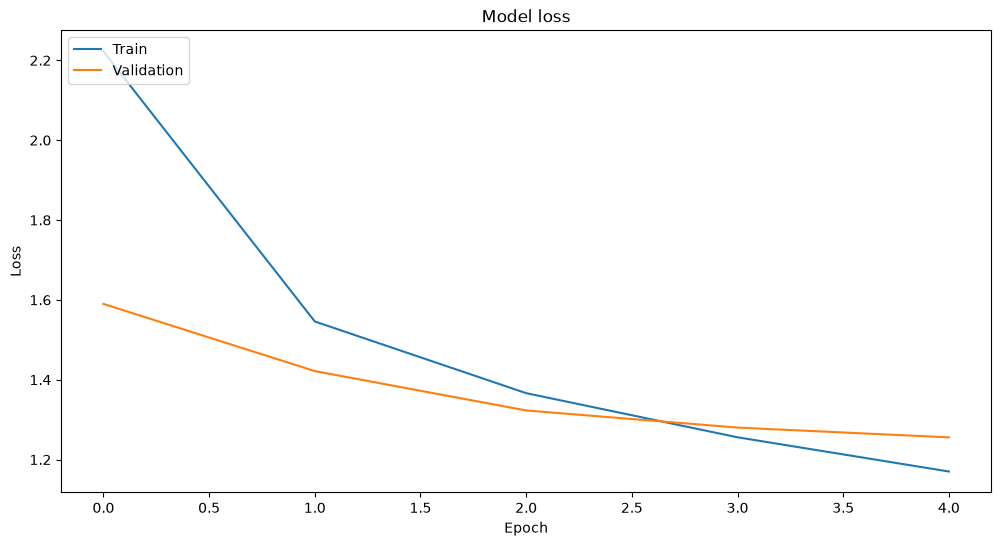

In [17]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

 5/32 ━━━━━━━━━━━━━━━━━━━━ 2:40 6s/step

/home/afh/coding/model/ML/ml-env/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 248s 6s/step


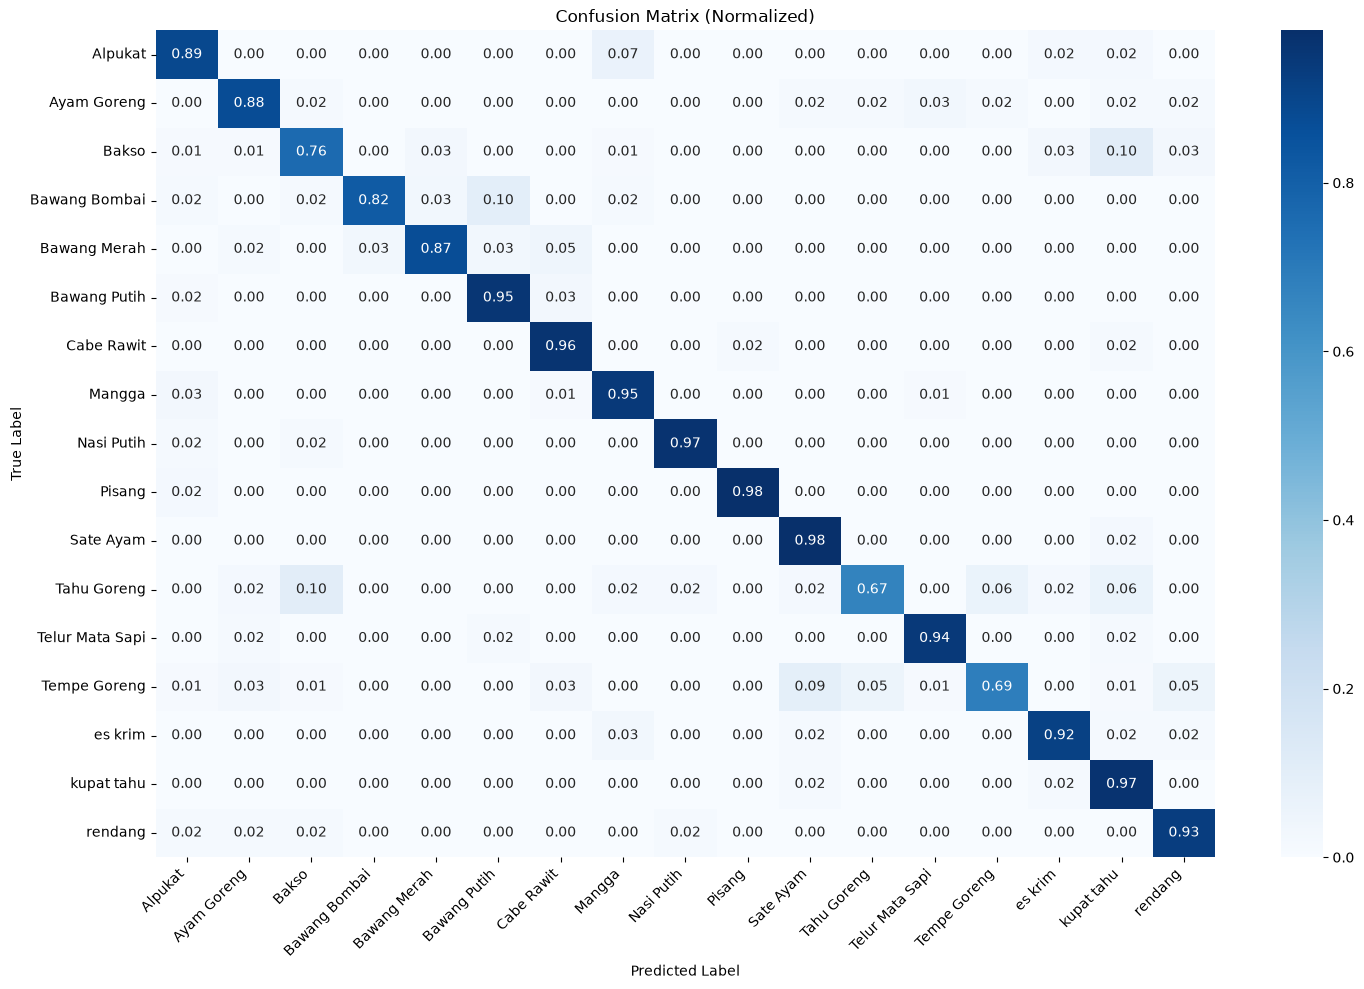


Classification Report:
                 precision    recall  f1-score   support

        Alpukat       0.82      0.89      0.85        46
    Ayam Goreng       0.89      0.88      0.88        65
          Bakso       0.84      0.76      0.80        67
  Bawang Bombai       0.96      0.82      0.88        61
   Bawang Merah       0.93      0.87      0.90        62
   Bawang Putih       0.88      0.95      0.91        66
     Cabe Rawit       0.87      0.96      0.91        54
         Mangga       0.90      0.95      0.92        73
     Nasi Putih       0.97      0.97      0.97        61
         Pisang       0.98      0.98      0.98        52
      Sate Ayam       0.82      0.98      0.89        51
    Tahu Goreng       0.86      0.67      0.75        48
Telur Mata Sapi       0.93      0.94      0.93        53
   Tempe Goreng       0.93      0.69      0.79        74
        es krim       0.92      0.92      0.92        61
     kupat tahu       0.79      0.97      0.87        65
      

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(
    model, 
    test_generator, 
    class_names=None, 
    title='Confusion Matrix',
    normalize=True
):
    """
    Fungsi untuk membuat dan memvisualisasikan Confusion Matrix
    
    Parameters:
    - model: Model yang sudah dilatih
    - test_generator: Generator data test
    - class_names: Nama-nama kelas
    - normalize: Apakah matrix dinormalisasi
    """
    
    # Reset generator
    test_generator.reset()
    
    # Ambil semua data test
    y_true = test_generator.classes
    
    # Prediksi menggunakan model
    y_pred = model.predict(test_generator)
    
    # Konversi prediksi ke kelas
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Jika class_names tidak disediakan, gunakan indeks kelas
    if class_names is None:
        class_names = list(test_generator.class_indices.keys())
    
    # Hitung confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    
    # Normalisasi jika diminta
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        title += ' (Normalized)'
    else:
        fmt = 'd'
    
    # Visualisasi
    plt.figure(figsize=(15, 10))
    
    # Confusion Matrix Heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        cmap='Blues', 
        fmt=fmt,
        xticklabels=class_names, 
        yticklabels=class_names
    )
    
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Cetak classification report
    print("\nClassification Report:")
    print(classification_report(
        y_true, 
        y_pred_classes, 
        target_names=class_names
    ))

def advanced_confusion_matrix_analysis(
    model, 
    test_generator, 
    class_names=None
):
    """
    Analisis mendalam Confusion Matrix
    """
    # Reset generator
    test_generator.reset()
    
    # Ambil semua data test
    y_true = test_generator.classes
    
    # Prediksi menggunakan model
    y_pred = model.predict(test_generator)
    
    # Konversi prediksi ke kelas
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Jika class_names tidak disediakan, gunakan indeks kelas
    if class_names is None:
        class_names = list(test_generator.class_indices.keys())
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    
    # Visualisasi Detail
    plt.figure(figsize=(20, 15))
    
    # Subplot 1: Normalized Confusion Matrix
    plt.subplot(2, 2, 1)
    sns.heatmap(
        cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], 
        annot=True, 
        cmap='Blues', 
        fmt='.2f',
        xticklabels=class_names, 
        yticklabels=class_names
    )
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    
    # Subplot 2: Raw Confusion Matrix
    plt.subplot(2, 2, 2)
    sns.heatmap(
        cm, 
        annot=True, 
        cmap='Reds', 
        fmt='d',
        xticklabels=class_names, 
        yticklabels=class_names
    )
    plt.title('Raw Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    
    # Subplot 3: Precision per Class
    precision_per_class = cm.diagonal() / cm.sum(axis=0)
    plt.subplot(2, 2, 3)
    plt.bar(class_names, precision_per_class)
    plt.title('Precision per Class')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Precision')
    
    # Subplot 4: Recall per Class
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    plt.subplot(2, 2, 4)
    plt.bar(class_names, recall_per_class)
    plt.title('Recall per Class')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Recall')
    
    plt.tight_layout()
    plt.show()
    
    # Identifikasi Kesalahan Terburuk
    misclassification_analysis(
        y_true, 
        y_pred_classes, 
        class_names
    )

def misclassification_analysis(
    y_true, 
    y_pred, 
    class_names, 
    top_n=5
):
    """
    Analisis kesalahan klasifikasi terburuk
    """
    # Temukan indeks prediksi salah
    misclassified_indices = np.where(y_true != y_pred)[0]
    
    # Hitung frekuensi kesalahan
    misclass_freq = {}
    for true, pred in zip(y_true[misclassified_indices], 
                          y_pred[misclassified_indices]):
        key = (class_names[true], class_names[pred])
        misclass_freq[key] = misclass_freq.get(key, 0) + 1
    
    # Urutkan kesalahan terburuk
    worst_misclassifications = sorted(
        misclass_freq.items(), 
        key=lambda x: x[1], 
        reverse=True
    )[:top_n]
    
    print("\nTop Worst Misclassifications:")
    for (true_class, pred_class), freq in worst_misclassifications:
        print(f"{true_class} misclassified as {pred_class}: {freq} times")

# Pastikan test_images adalah generator yang valid dan model adalah model yang sudah dilatih
# Misalnya:
# test_images = ImageDataGenerator().flow_from_directory('path_to_test_images')
# model = tf.keras.models.load_model('path_to_model')

# Cara Penggunaan
# Dapatkan nama kelas dari generator
class_names = list(test_images.class_indices.keys())

# Reset generator sebelum digunakan
test_images.reset()

# Plot Confusion Matrix
plot_confusion_matrix(
    model, 
    test_images, 
    class_names=class_names
)


# Prediction

Found 6031 files belonging to 17 classes.


W0000 00:00:1782620954.909948   81795 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1782620954.909949   81794 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile



Jumlah gambar per kategori:
Label
es krim            800
kupat tahu         366
rendang            352
Sate Ayam          347
Nasi Putih         337
Bawang Bombai      334
Bakso              332
Alpukat            325
Tempe Goreng       320
Mangga             317
Pisang             317
Ayam Goreng        315
Cabe Rawit         299
Tahu Goreng        291
Telur Mata Sapi    283
Bawang Merah       283
Bawang Putih       258
Name: count, dtype: int64
✔️  Mengambil 300 gambar dari kategori: rendang
✔️  Mengambil 300 gambar dari kategori: Mangga
✔️  Mengambil 300 gambar dari kategori: Nasi Putih
✔️  Mengambil 300 gambar dari kategori: Ayam Goreng
✔️  Mengambil 300 gambar dari kategori: Sate Ayam
✔️  Mengambil 300 gambar dari kategori: es krim
✔️  Mengambil 300 gambar dari kategori: Bawang Bombai
✔️  Mengambil 300 gambar dari kategori: Tempe Goreng
✔️  Mengambil 258 gambar dari kategori: Bawang Putih
✔️  Mengambil 300 gambar dari kategori: Pisang
✔️  Mengambil 300 gambar dari kategori: Alpuk

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


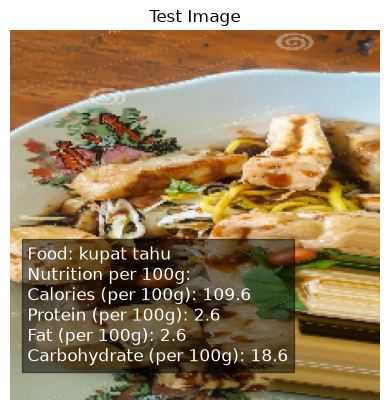

In [19]:
from prediction import predict_food
from Preprocessing import train_images

csv_path = 'Data/nutrition.csv'
model_path = 'smartbite.h5'
test_image_path = 'kuplat.jpeg'

# Step 3: Predict on a sample image
result = predict_food(test_image_path, model_path, csv_path, train_images.class_indices)

# Show the image using matplotlib
img = tf.keras.preprocessing.image.load_img(test_image_path, target_size=(224, 224))
# Add the nutrition information text inside the image
plt.imshow(img)
plt.title("Test Image")
plt.axis('off')

# Add text to the image
nutrition_text = result.replace('\n', '\n')
plt.text(10, 200, nutrition_text, fontsize=12, color='white', bbox=dict(facecolor='black', alpha=0.5))

plt.show()

In [20]:
model.save('smartbite.h5')